> **@paxton** these were run outside the Docker container (Docker would not start locally), against
> a copy of `analysis_helpers` with `DATA_DIR` repointed at the repo — i.e. what the bind-mount does,
> with the notebook itself unmodified. Worth re-running in the container to confirm.

# Which episode events do participants recount, and does that change across the delay?

Everything below operates on `event_matches`, the mapping from each recall event onto the episode
event it describes. A participant who returns to the same episode event more than once within a
session is counted only once, so these analyses are about *which* events were described, not how
often.

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import spearmanr, wilcoxon

from analysis_helpers import Episode, Participant
from analysis_helpers.functions import (
    bootstrap_ci,
    cochrans_q,
    events_recounted,
    format_stats,
    rank_biserial,
    show_source
)

## Functions

The helpers used here all live in `analysis_helpers.functions`.

In [2]:
show_source(events_recounted)

In [3]:
show_source(cochrans_q)

In [4]:
show_source(rank_biserial)

## Load data

In [5]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()
n_events = len(atlep1.events)
n_participants = len(participants)

print(f'{n_participants} participants, {n_events} episode events')

53 participants, 20 episode events


In [6]:
imm_recounted = np.array(
    [events_recounted(p.event_matches['atlep1'], n_events) for p in participants]
)
del_recounted = np.array(
    [events_recounted(p.event_matches['delayed'], n_events) for p in participants]
)

# proportion of participants who described each episode event
imm_rates = imm_recounted.mean(axis=0)
del_rates = del_recounted.mean(axis=0)

## Do participants recount fewer episode events after the delay?

One-sided, since the directional hypothesis is that fewer events survive the delay. The
rank-biserial correlation is the effect size that accompanies a Wilcoxon signed-rank test, and the
confidence interval is on the mean decline itself (in events), which is the quantity readers care
about.

In [7]:
n_imm = imm_recounted.sum(axis=1)
n_del = del_recounted.sum(axis=1)
decline = n_imm - n_del

T, p = wilcoxon(n_imm, n_del, alternative='greater')
T, p = T.item(), p.item()
r = rank_biserial(decline)
ci_lo, ci_hi = bootstrap_ci(decline, np.mean)

print(f'episode events recounted immediately: mean={n_imm.mean():.2f}, s.d.={n_imm.std(ddof=1):.2f}')
print(f'episode events recounted after delay: mean={n_del.mean():.2f}, s.d.={n_del.std(ddof=1):.2f}')
print(f'mean decline: {decline.mean():.2f} events, 95% CI [{ci_lo:.2f}, {ci_hi:.2f}]')
print(f'{T=}, {p=:.4e}, rank-biserial {r=:.3f}, n={n_participants}')

episode events recounted immediately: mean=16.98, s.d.=2.22
episode events recounted after delay: mean=16.26, s.d.=2.51
mean decline: 0.72 events, 95% CI [0.23, 1.19]
T=581.0, p=3.3742e-03, rank-biserial r=0.490, n=53


## Are some episode events more likely to be recounted than others?

Cochran's Q rather than a chi-squared goodness-of-fit test on the per-event totals: participants
describe most of the events, and can describe each at most once, so the totals are far less variable
under the null than independent draws would be. Kendall's W rescales Q to [0, 1] as an effect size,
which matters here because with 53 participants even a small departure from uniformity is highly
significant.

In [8]:
for session, recounted in (('immediate', imm_recounted), ('delayed', del_recounted)):
    Q, df, p = cochrans_q(recounted)
    W = Q / (n_participants * (n_events - 1))    # Kendall's W
    rates = recounted.mean(axis=0)
    print(f'{session} recall:')
    print(f'  proportion of participants recounting each episode event: '
          f'min={rates.min():.2f}, max={rates.max():.2f}, mean={rates.mean():.2f}')
    print(f'  {Q=:.2f}, {df=}, {p=:.4e}, Kendall\'s {W=:.3f}')

immediate recall:
  proportion of participants recounting each episode event: min=0.64, max=0.96, mean=0.85
  Q=75.07, df=19, p=1.2936e-08, Kendall's W=0.075
delayed recall:
  proportion of participants recounting each episode event: min=0.58, max=0.98, mean=0.81
  Q=73.82, df=19, p=2.1086e-08, Kendall's W=0.073


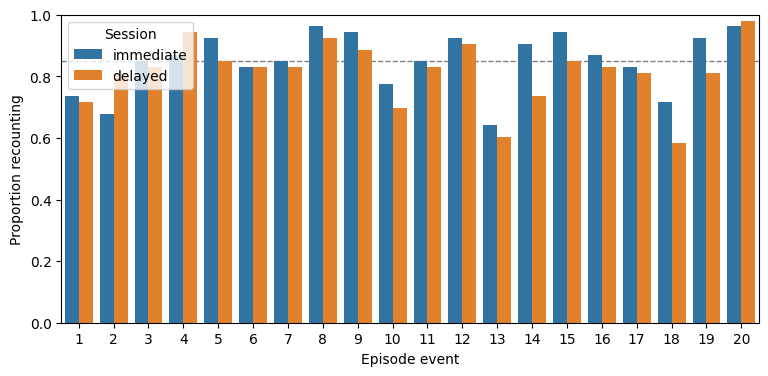

In [9]:
df = pd.DataFrame(columns=('Session', 'Episode event', 'Proportion recounting'))
df['Session'] = np.repeat(['immediate', 'delayed'], n_events)
df['Episode event'] = np.tile(np.arange(1, n_events + 1), 2)
df['Proportion recounting'] = np.concatenate((imm_rates, del_rates))

fig, ax = plt.subplots(1, figsize=(9, 4))
ax = sns.barplot(df, x='Episode event', y='Proportion recounting', hue='Session')
ax.axhline(imm_rates.mean(), c='grey', ls='--', lw=1, zorder=0)
ax.set_ylim(0, 1)
plt.show()

## Does the distribution of recounted events change across the delay?

Two-sided (`spearmanr`'s default), and note the correlation is symmetric: it establishes that the
two profiles agree, not that the immediate one produced the delayed one. n here is the number of
**episode events** (20), not the number of participants.

In [10]:
rho, p = spearmanr(imm_rates, del_rates)
rho, p = rho.item(), p.item()
print(f'immediate vs delayed proportions across episode events: {rho=:.3f}, {p=:.4e}, n={n_events}')

immediate vs delayed proportions across episode events: rho=0.795, p=2.8189e-05, n=20


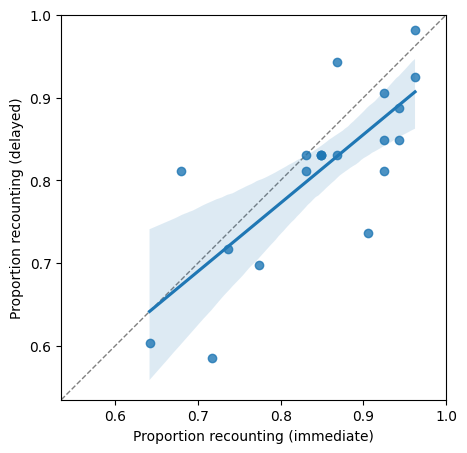

In [11]:
fig, ax = plt.subplots(1, figsize=(5, 5))
ax = sns.regplot(x=imm_rates, y=del_rates)
lims = (min(imm_rates.min(), del_rates.min()) - 0.05, 1)
ax.plot(lims, lims, c='grey', ls='--', lw=1, zorder=0)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Proportion recounting (immediate)')
ax.set_ylabel('Proportion recounting (delayed)')
ax.set_box_aspect(1)
plt.show()